### Q3: [Model and Evaluation]

Now, we need to do the following:
1. Read the created csv files from Q2.
2. Create a CNN-based model for land use classification.
3. Training the model and evaluating F1 score, accuracy.
4. Confusion matrix

PS: During this task, I used a basic CNN model where I took some help from chatgpt.

Note: I had to use cpu version for pytorch due to internal gpu error on my device.

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

# Set device to CPU (or GPU if it magically becomes available!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

# Map labels to integers
unique_labels = sorted(train_df['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(f"Class mapping: {label_to_idx}")

# Custom Dataset Class
class LandUseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename'] 
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        
        label_str = self.df.iloc[idx]['label']
        label = label_to_idx[label_str]

        if self.transform:
            image = self.transform(image)
        return image, label

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_directory = "../data/rgb"

train_dataset = LandUseDataset(train_df, img_dir=img_directory, transform=transform)
test_dataset = LandUseDataset(test_df, img_dir=img_directory, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Class mapping: {'Bare': 0, 'Built-up': 1, 'Cropland': 2, 'Vegetation': 3, 'Water': 4, 'Wetland': 5}


In [7]:
# A simple custom CNN optimized to run fast on CPU
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        # Feature Extraction Layers
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 16 x 64 x 64
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32 x 32 x 32
        )
        
        # Classification Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3), # Helps prevent overfitting
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize model
model = SimpleCNN(num_classes=len(unique_labels)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model architecture compiled and ready!")

Model architecture compiled and ready!


In [10]:
# checked for 5 epochs, loss was steeply decreasing 
# 10 epochs 
num_epochs = 10

print("Starting Training Loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Optimize
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting Training Loop...
Epoch [1/10], Training Loss: 0.1118
Epoch [2/10], Training Loss: 0.0591
Epoch [3/10], Training Loss: 0.0453
Epoch [4/10], Training Loss: 0.0337
Epoch [5/10], Training Loss: 0.0292
Epoch [6/10], Training Loss: 0.0157
Epoch [7/10], Training Loss: 0.0244
Epoch [8/10], Training Loss: 0.0229
Epoch [9/10], Training Loss: 0.0132
Epoch [10/10], Training Loss: 0.0355
Training Complete!


Evaluating on test data...
Test Accuracy: 0.7800
Test F1-Score (Weighted): 0.7461


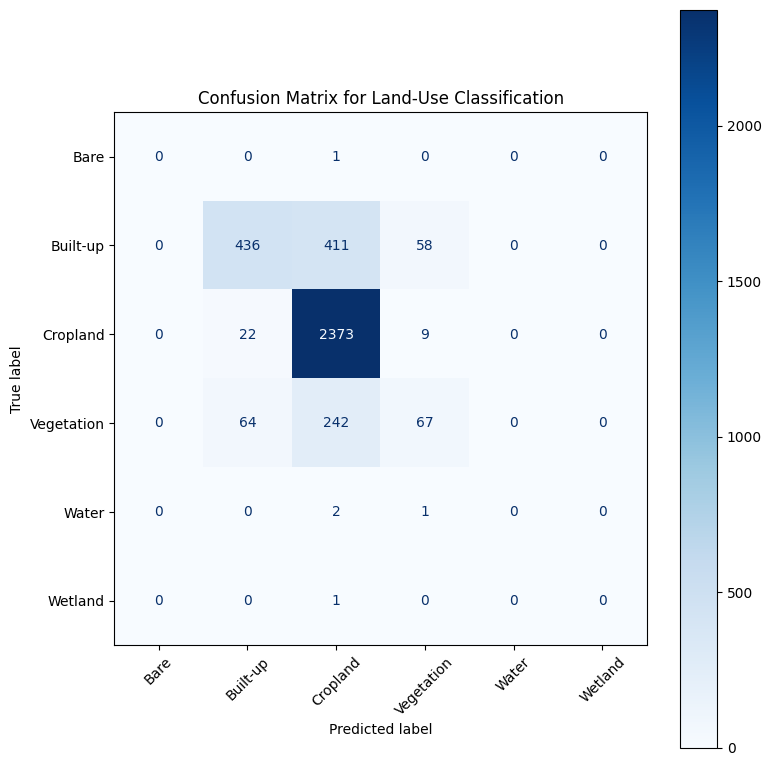

In [ ]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating on test data...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1-Score (Weighted): {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Land-Use Classification")
plt.tight_layout()
plt.show()

##### Interpretations from the Result: 
1. Overall accuracy of ~78% is achieved as a basic CNN based at 10 epochs is used.  
2. 74% F1 score implies a bit of class imbalance in the data. Like, Around Cropland and {Vegetation, Built-Up} there have been a decent number of false predictions.  
3. Due to highly skewed data distribution at cropland, model learns it a bit too well and there is a considerably large number for it.

Underlying reason: Due to limited RGB equipments, the models simply confuses cropland and vegetation due to chlorophyll concentration, Similar issue for built up as well.